# 05 Predictor Agreement

Question: Do predictors agree more than annotations do?

This notebook summarizes pairwise agreement between human-proteome predictor outputs and compares that agreement with the experimental annotation-agreement estimates from the annotation ceiling analysis.

## Method

The predictor comparison uses matched residues from the same human proteome proteins. For every predictor pair, the script reports residue-level Spearman/Pearson correlation, protein-mean Spearman/Pearson correlation, and z-score MAE. CheZOD and pLDDT are negated before comparison because their native direction is lower = more disorder.

The annotation comparison joins each predictor pair to the matching annotation-ceiling pair. The main diagnostic is the difference between predictor Spearman and annotation Spearman. Positive values mean the trained predictors agree more strongly with each other than the underlying annotations agree on overlapping experimental data.

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"
OUTPUT_DIR = RESULTS / "compare_predictors_with_seth_and_iupred3_and_adopt_and_metapredict"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pairwise_csv = OUTPUT_DIR / "pairwise_agreement.csv"
contested_csv = OUTPUT_DIR / "contested_regions.csv"

predictor_args = [
    "trizod=results/human_proteome/UdonPred/trizod",
    "chezod=results/human_proteome/UdonPred/chezod",
    "softdis=results/human_proteome/UdonPred/softdis",
    "pdbflex=results/human_proteome/UdonPred/pdbflex",
    "atlas=results/human_proteome/UdonPred/atlas",
    "plddt=results/human_proteome/UdonPred/plddt",
    "disprot=results/human_proteome/UdonPred/disprot",
    "SETH=results/human_proteome/SETH/seth_human_proteome.caid",
    "IUPred3=results/human_proteome/IUPred3",
    "ADOPT=results/human_proteome/ADOPT",
    "metapredict=results/human_proteome/metapredict/metapredict_human_proteome.caid",
]

if pairwise_csv.exists() and contested_csv.exists():
    print("Predictor comparison results already exist, skipping computation.")
else:
    print("Running predictor comparison...")
    cmd = [sys.executable, str(ROOT / "scripts" / "compare_predictors.py")]
    for value in predictor_args:
        cmd.extend(["--predictor", value])
    cmd.extend(["--output-dir", str(OUTPUT_DIR)])
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    result.check_returncode()

pairwise = pd.read_csv(pairwise_csv)
contested_regions = pd.read_csv(contested_csv)

pairwise.head()

Predictor comparison results already exist, skipping computation.


,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
0,ADOPT,IUPred3,20659,9861047,0.637572,0.712196,0.600289,0.704414,0.741337,0.539165
1,ADOPT,SETH,20659,9861047,0.808299,0.875295,0.381239,0.933621,0.948784,0.238737
2,ADOPT,atlas,20659,9861047,0.716855,0.718688,0.548962,0.850849,0.804915,0.448031
3,ADOPT,chezod,20659,9861047,0.803898,0.873617,0.392639,0.919019,0.935593,0.264353
4,ADOPT,disprot,20659,9861047,0.784306,0.880197,0.378025,0.923026,0.935496,0.265379


## Predictor-Predictor Agreement

Residue-level correlation asks whether predictors rank individual residues similarly. Protein-level correlation asks whether they agree on which proteins are globally more disorder-prone.

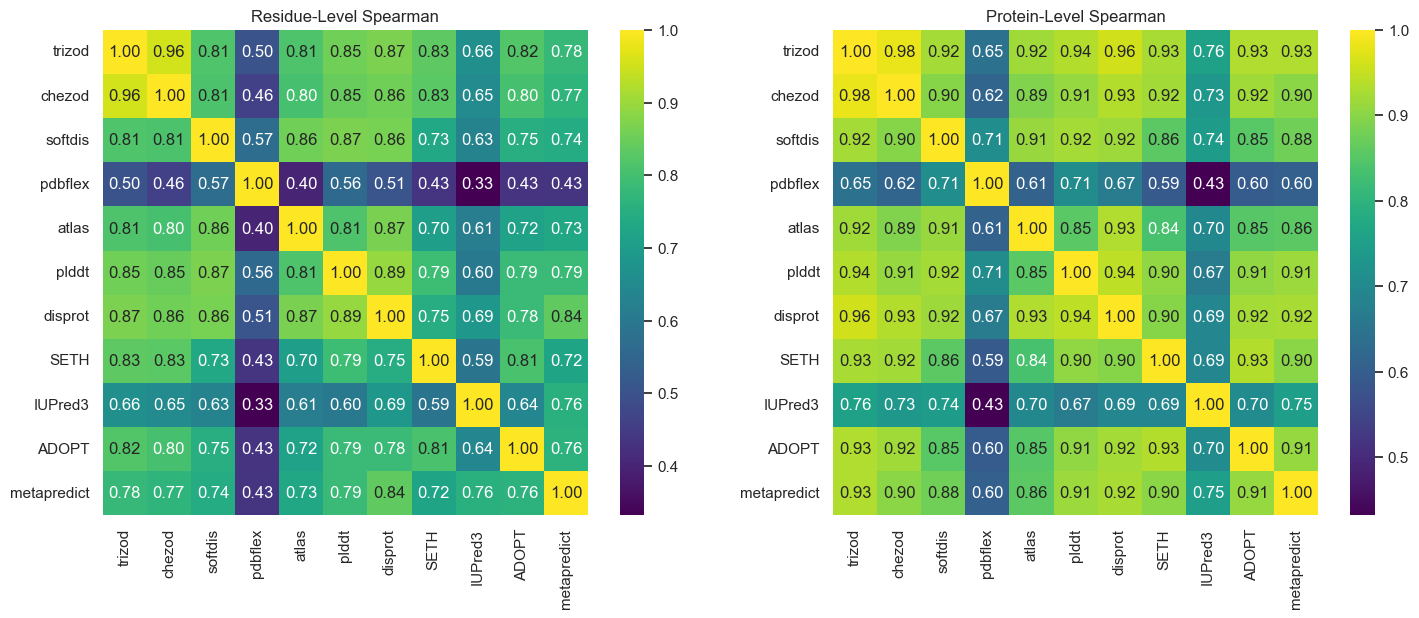

,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
39,chezod,trizod,20659,11456702,0.955227,0.962036,0.221924,0.980046,0.982735,0.139842
42,disprot,plddt,20659,11456702,0.894091,0.940588,0.249930,0.942352,0.927614,0.276945
52,plddt,softdis,20659,11456702,0.868132,0.910745,0.303695,0.923485,0.918080,0.262247
44,disprot,trizod,20659,11456702,0.867406,0.938770,0.246672,0.958151,0.954381,0.206561
28,atlas,disprot,20659,11456702,0.866774,0.799895,0.429647,0.933264,0.888480,0.324899
43,disprot,softdis,20659,11456702,0.863369,0.877606,0.330251,0.917692,0.881364,0.307246
32,atlas,softdis,20659,11456702,0.855393,0.789845,0.459573,0.912408,0.849228,0.359305
34,chezod,disprot,20659,11456702,0.855081,0.925031,0.292262,0.934552,0.952239,0.230152
53,plddt,trizod,20659,11456702,0.854218,0.924289,0.287333,0.935306,0.930619,0.283650
37,chezod,plddt,20659,11456702,0.845469,0.915369,0.320752,0.909845,0.917951,0.313763


In [2]:
predictor_order = [
    name
    for name in ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot", "SETH", "IUPred3", "ADOPT", "metapredict"]
    if name in set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])
]

def pair_matrix(value_column):
    matrix = pd.DataFrame(np.nan, index=predictor_order, columns=predictor_order)
    for predictor in predictor_order:
        matrix.loc[predictor, predictor] = 1.0
    for row in pairwise.itertuples(index=False):
        matrix.loc[row.predictor_a, row.predictor_b] = getattr(row, value_column)
        matrix.loc[row.predictor_b, row.predictor_a] = getattr(row, value_column)
    return matrix

residue_spearman_matrix = pair_matrix("residue_spearman")
protein_spearman_matrix = pair_matrix("protein_spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    residue_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(residue_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residue-Level Spearman")
sns.heatmap(
    protein_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(protein_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Protein-Level Spearman")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_spearman_heatmaps.png", dpi=200)
plt.show()

pairwise.sort_values("residue_spearman", ascending=False)

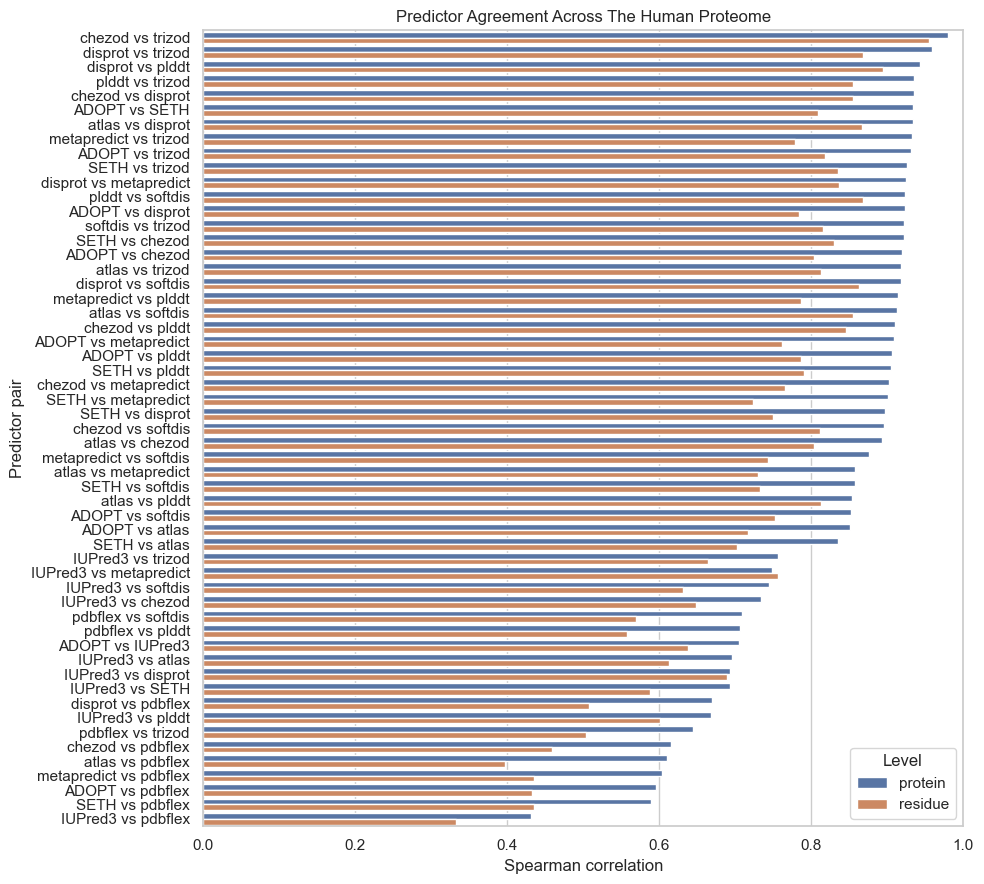

In [3]:
agreement_long = pairwise.melt(
    id_vars=["predictor_a", "predictor_b", "common_proteins", "matched_residues"],
    value_vars=["residue_spearman", "protein_spearman"],
    var_name="level",
    value_name="spearman",
)
agreement_long["pair"] = agreement_long["predictor_a"] + " vs " + agreement_long["predictor_b"]
agreement_long["level"] = agreement_long["level"].str.replace("_spearman", "", regex=False)

plot_data = agreement_long.sort_values(["level", "spearman"], ascending=[True, False])

plt.figure(figsize=(10, 9))
sns.barplot(data=plot_data, x="spearman", y="pair", hue="level")
plt.xlabel("Spearman correlation")
plt.ylabel("Predictor pair")
plt.title("Predictor Agreement Across The Human Proteome")
plt.xlim(0, 1)
plt.legend(title="Level", loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_pairwise_spearman_bars.png", dpi=200)
plt.show()

## Predictor Agreement vs Annotation Agreement

The direct comparison to experimental annotation agreement is restricted to the seven UdonPred dataset-specific models. External predictors are kept in the predictor-agreement analysis, but they do not have a one-to-one annotation source in this project setup.

The annotation agreement values are reused from the experimental ceiling analysis. Positive gaps mean that two trained predictors agree more strongly on the human proteome than the corresponding experimental annotations agree on their overlapping labeled residues or proteins.


In [4]:
ANNOTATION_CEILING_CSV = RESULTS / "annotation_ceiling" / "annotation_ceiling_summary.csv"
UDONPRED_DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]

annotation_ceiling = pd.read_csv(ANNOTATION_CEILING_CSV)

def normalized_pair_key(left, right):
    return "__".join(sorted([str(left).lower(), str(right).lower()]))

udon_pairwise = pairwise[
    pairwise["predictor_a"].str.lower().isin(UDONPRED_DATASETS)
    & pairwise["predictor_b"].str.lower().isin(UDONPRED_DATASETS)
].copy()
udon_pairwise["pair_key"] = [
    normalized_pair_key(left, right)
    for left, right in zip(udon_pairwise["predictor_a"], udon_pairwise["predictor_b"])
]
udon_pairwise["pair"] = udon_pairwise["predictor_a"] + " vs " + udon_pairwise["predictor_b"]

annotation_ceiling["pair_key"] = [
    normalized_pair_key(left, right)
    for left, right in zip(annotation_ceiling["dataset_a"], annotation_ceiling["dataset_b"])
]
annotation_counts = (
    annotation_ceiling.sort_values(["pair_key", "metric"])
    .groupby("pair_key", as_index=False)
    .agg(
        annotation_dataset_a=("dataset_a", "first"),
        annotation_dataset_b=("dataset_b", "first"),
        annotation_match_mode=("match_mode", "first"),
        n_annotation_proteins=("n_proteins_overlap", "max"),
        n_annotation_residues=("n_residues_compared", "max"),
    )
)
annotation_values = (
    annotation_ceiling[annotation_ceiling["metric"].isin(["spearman", "protein_spearman"])]
    .pivot_table(index="pair_key", columns="metric", values="value", aggfunc="first")
    .reset_index()
    .rename(
        columns={
            "spearman": "annotation_residue_spearman",
            "protein_spearman": "annotation_protein_spearman",
        }
    )
)
annotation_pair_summary = annotation_counts.merge(annotation_values, on="pair_key", how="left")

udon_predictor_vs_annotation = udon_pairwise.merge(
    annotation_pair_summary,
    on="pair_key",
    how="left",
)
udon_predictor_vs_annotation["residue_gap"] = (
    udon_predictor_vs_annotation["residue_spearman"]
    - udon_predictor_vs_annotation["annotation_residue_spearman"]
)
udon_predictor_vs_annotation["protein_gap"] = (
    udon_predictor_vs_annotation["protein_spearman"]
    - udon_predictor_vs_annotation["annotation_protein_spearman"]
)
udon_predictor_vs_annotation["annotation_overlap_confidence"] = np.select(
    [
        udon_predictor_vs_annotation["n_annotation_residues"].fillna(0) == 0,
        (udon_predictor_vs_annotation["n_annotation_residues"].fillna(0) < 100)
        | (udon_predictor_vs_annotation["n_annotation_proteins"].fillna(0) < 3),
    ],
    ["no overlap", "low overlap"],
    default="usable overlap",
)

comparison_columns = [
    "pair",
    "common_proteins",
    "matched_residues",
    "residue_spearman",
    "annotation_residue_spearman",
    "residue_gap",
    "protein_spearman",
    "annotation_protein_spearman",
    "protein_gap",
    "n_annotation_proteins",
    "n_annotation_residues",
    "annotation_overlap_confidence",
]
udon_predictor_vs_annotation[comparison_columns].sort_values("residue_gap", ascending=False)


,pair,common_proteins,matched_residues,residue_spearman,annotation_residue_spearman,residue_gap,protein_spearman,annotation_protein_spearman,protein_gap,n_annotation_proteins,n_annotation_residues,annotation_overlap_confidence
11,disprot vs pdbflex,20659,11456702,0.507872,-0.151455,0.659327,0.669268,0.464286,0.204982,7,2335,usable overlap
0,atlas vs chezod,20659,11456702,0.804006,0.220828,0.583178,0.892633,NaN,NaN,2,372,low overlap
15,pdbflex vs plddt,20659,11456702,0.557118,0.011500,0.545618,0.705861,0.485714,0.220147,6,1412,usable overlap
4,atlas vs softdis,20659,11456702,0.855393,0.315038,0.540355,0.912408,0.487745,0.424663,17,1558,usable overlap
3,atlas vs plddt,20659,11456702,0.813176,0.295052,0.518124,0.854050,NaN,NaN,2,424,low overlap
16,pdbflex vs softdis,20659,11456702,0.568781,0.077090,0.491691,0.708999,0.040218,0.668781,748,123212,usable overlap
9,chezod vs softdis,20659,11456702,0.811431,0.332540,0.478891,0.896202,NaN,NaN,1,72,low overlap
10,chezod vs trizod,20659,11456702,0.955227,0.481978,0.473249,0.980046,NaN,NaN,1,138,low overlap
13,disprot vs softdis,20659,11456702,0.863369,0.488921,0.374448,0.917692,0.761905,0.155787,8,2642,usable overlap
19,plddt vs trizod,20659,11456702,0.854218,0.504646,0.349572,0.935306,1.000000,-0.064694,2,283,low overlap


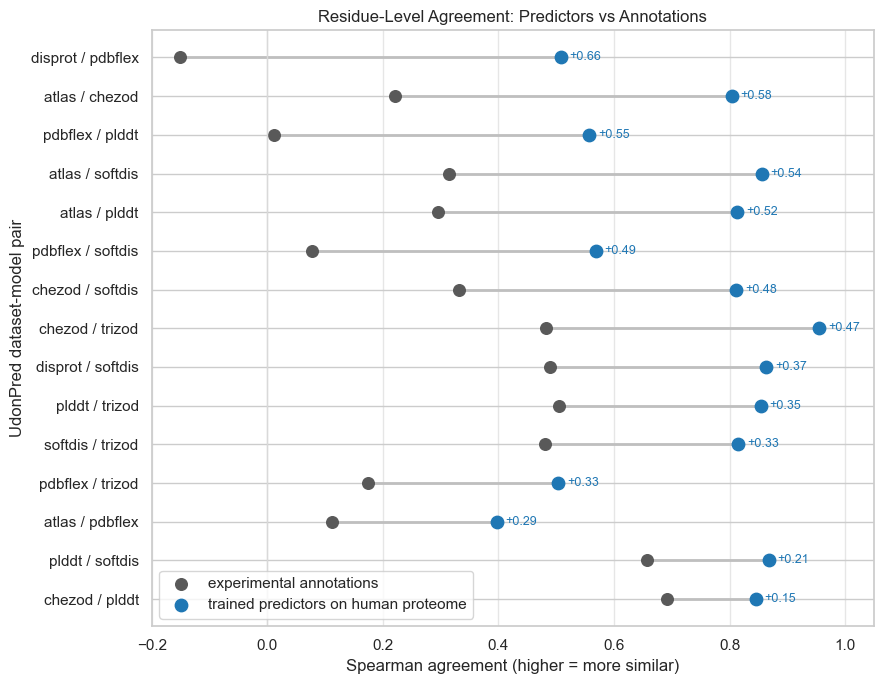

In [9]:
plot_data = udon_predictor_vs_annotation.dropna(
    subset=["annotation_residue_spearman", "residue_spearman"]
).copy()
plot_data = plot_data.sort_values("residue_gap", ascending=True).reset_index(drop=True)
plot_data["pair_label"] = plot_data["pair"].str.replace(" vs ", " / ", regex=False)
plot_data["y"] = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 7))
for row in plot_data.itertuples(index=False):
    ax.plot(
        [row.annotation_residue_spearman, row.residue_spearman],
        [row.y, row.y],
        color="0.75",
        linewidth=2,
        zorder=1,
    )

ax.scatter(
    plot_data["annotation_residue_spearman"],
    plot_data["y"],
    color="0.35",
    s=70,
    label="experimental annotations",
    zorder=2,
)
ax.scatter(
    plot_data["residue_spearman"],
    plot_data["y"],
    color="tab:blue",
    s=80,
    label="trained predictors on human proteome",
    zorder=3,
)

for row in plot_data.itertuples(index=False):
    ax.text(
        max(row.annotation_residue_spearman, row.residue_spearman) + 0.015,
        row.y,
        f"{row.residue_gap:+.2f}",
        va="center",
        fontsize=9,
        color="tab:blue" if row.residue_gap >= 0 else "tab:orange",
    )

ax.set_yticks(plot_data["y"])
ax.set_yticklabels(plot_data["pair_label"])
ax.set_xlabel("Spearman agreement (higher = more similar)")
ax.set_ylabel("UdonPred dataset-model pair")
ax.set_title("Residue-Level Agreement: Predictors vs Annotations")
ax.set_xlim(-0.2, 1.05)
ax.axvline(0, color="0.85", linewidth=1)
ax.grid(axis="x", color="0.9")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_vs_annotation_residue_scatter.png", dpi=200)
plt.show()


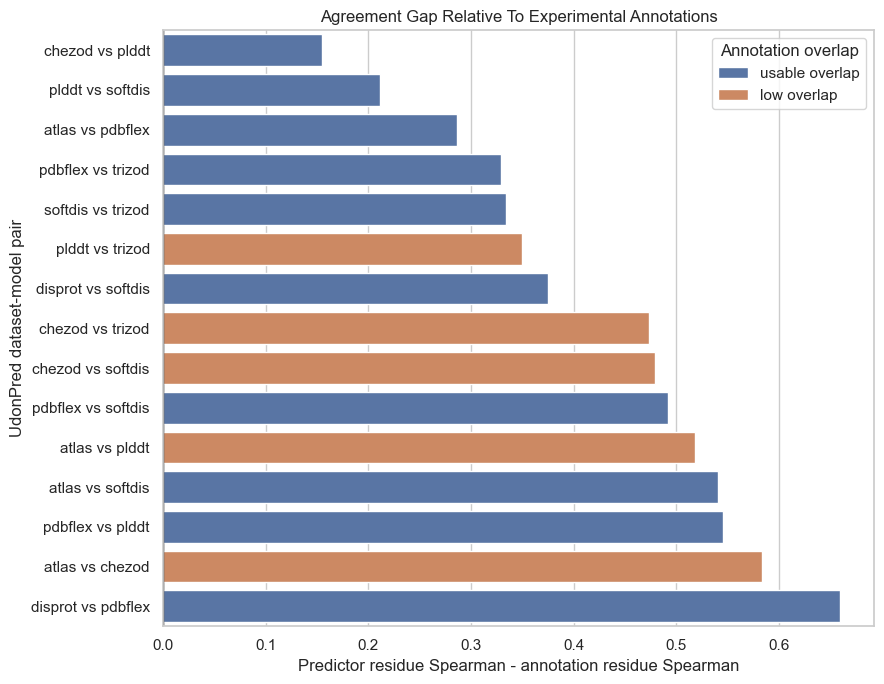

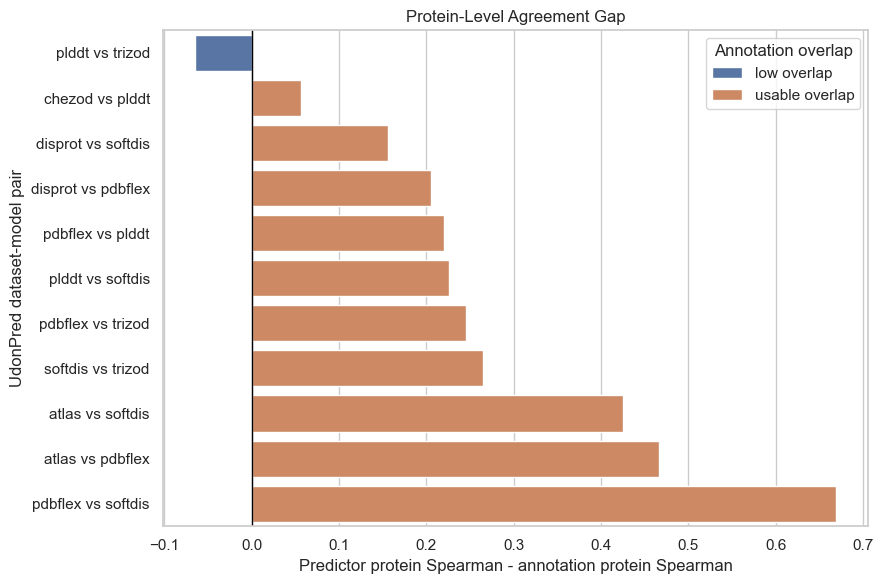

In [11]:
gap_data = udon_predictor_vs_annotation.dropna(subset=["residue_gap"]).sort_values("residue_gap")

plt.figure(figsize=(9, 7))
sns.barplot(
    data=gap_data,
    x="residue_gap",
    y="pair",
    hue="annotation_overlap_confidence",
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predictor residue Spearman - annotation residue Spearman")
plt.ylabel("UdonPred dataset-model pair")
plt.title("Agreement Gap Relative To Experimental Annotations")
plt.legend(title="Annotation overlap", loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_residue_gap.png", dpi=200)
plt.show()

protein_gap_data = udon_predictor_vs_annotation.dropna(subset=["protein_gap"]).sort_values("protein_gap")
plt.figure(figsize=(9, 6))
sns.barplot(
    data=protein_gap_data,
    x="protein_gap",
    y="pair",
    hue="annotation_overlap_confidence",
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predictor protein Spearman - annotation protein Spearman")
plt.ylabel("UdonPred dataset-model pair")
plt.title("Protein-Level Agreement Gap")
plt.legend(title="Annotation overlap", loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_protein_gap.png", dpi=200)
plt.show()


## External Predictors

The external methods remain useful as reference predictors on the same human-proteome panel. They are not assigned an annotation-ceiling baseline here because their training data do not map cleanly to one of the seven UdonPred annotation sources.


In [7]:
external_predictors = sorted(
    (set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])) - set(UDONPRED_DATASETS)
)
external_pairwise = pairwise[
    pairwise["predictor_a"].isin(external_predictors)
    | pairwise["predictor_b"].isin(external_predictors)
].copy()
external_pairwise["pair"] = external_pairwise["predictor_a"] + " vs " + external_pairwise["predictor_b"]
external_pairwise.sort_values("residue_spearman", ascending=False)[
    ["pair", "common_proteins", "matched_residues", "residue_spearman", "protein_spearman", "residue_zscore_mae"]
]


,pair,common_proteins,matched_residues,residue_spearman,protein_spearman,residue_zscore_mae
40,disprot vs metapredict,20659,11456702,0.836354,0.924590,0.265906
26,SETH vs trizod,20659,11456702,0.834648,0.925336,0.348158
20,SETH vs chezod,20659,11456702,0.830236,0.922232,0.372125
9,ADOPT vs trizod,20659,9861047,0.817652,0.931511,0.373241
1,ADOPT vs SETH,20659,9861047,0.808299,0.933621,0.381239
3,ADOPT vs chezod,20659,9861047,0.803898,0.919019,0.392639
24,SETH vs plddt,20659,11456702,0.789818,0.904977,0.364516
46,metapredict vs plddt,20659,11456702,0.786024,0.914050,0.340356
7,ADOPT vs plddt,20659,9861047,0.785948,0.906197,0.385563
4,ADOPT vs disprot,20659,9861047,0.784306,0.923026,0.378025


### External Predictors vs UdonPred Consensus

To include external predictors without assigning them an artificial annotation baseline, compare each external method to a scale-normalized consensus of the seven UdonPred dataset-specific models. UdonPred models are also compared to a leave-one-out UdonPred consensus to provide context for how close a method is to the shared UdonPred signal.


In [8]:
import importlib.util
import sys

compare_predictors_spec = importlib.util.spec_from_file_location(
    "compare_predictors_module",
    ROOT / "scripts" / "compare_predictors.py",
)
compare_predictors_module = importlib.util.module_from_spec(compare_predictors_spec)
sys.modules[compare_predictors_spec.name] = compare_predictors_module
compare_predictors_spec.loader.exec_module(compare_predictors_module)

predictor_paths = {}
for value in predictor_args:
    name, relative_path = compare_predictors_module.parse_predictor_argument(value)
    predictor_paths[name] = ROOT / relative_path

negated_predictors = {name.lower() for name in compare_predictors_module.DEFAULT_NEGATED_PREDICTORS}
consensus_predictions = {}
for name, path in predictor_paths.items():
    loaded = compare_predictors_module.load_predictions(path)
    consensus_predictions[name] = compare_predictors_module.maybe_negate_scores(
        loaded,
        name,
        negated_predictors,
    )

scaled_consensus_predictions = compare_predictors_module.scale_predictions(
    consensus_predictions,
    method="zscore",
)

def compare_to_consensus(target_name, consensus_names, comparison_group):
    target = scaled_consensus_predictions[target_name]
    consensus_sources = [scaled_consensus_predictions[name] for name in consensus_names]
    common_ids = sorted(set(target).intersection(*(set(source) for source in consensus_sources)))

    residue_target = []
    residue_consensus = []
    protein_target = []
    protein_consensus = []

    for protein_id in common_ids:
        records = [source[protein_id] for source in consensus_sources]
        target_record = target[protein_id]
        length = min([len(record.scores) for record in records] + [len(target_record.scores)])
        if length == 0:
            continue
        consensus_matrix = np.vstack([record.scores[:length] for record in records])
        target_scores = target_record.scores[:length]
        mask = np.all(np.isfinite(consensus_matrix), axis=0) & np.isfinite(target_scores)
        if not np.any(mask):
            continue

        consensus_scores = np.mean(consensus_matrix[:, mask], axis=0)
        target_scores = target_scores[mask]
        residue_consensus.append(consensus_scores)
        residue_target.append(target_scores)
        protein_consensus.append(float(np.mean(consensus_scores)))
        protein_target.append(float(np.mean(target_scores)))

    if residue_target:
        flat_target = np.concatenate(residue_target)
        flat_consensus = np.concatenate(residue_consensus)
    else:
        flat_target = np.asarray([], dtype=np.float64)
        flat_consensus = np.asarray([], dtype=np.float64)

    protein_target = np.asarray(protein_target, dtype=np.float64)
    protein_consensus = np.asarray(protein_consensus, dtype=np.float64)
    return {
        "predictor": target_name,
        "comparison_group": comparison_group,
        "consensus_models": ", ".join(consensus_names),
        "common_proteins": len(common_ids),
        "matched_residues": len(flat_target),
        "residue_spearman_vs_udon_consensus": compare_predictors_module.correlation(
            flat_target,
            flat_consensus,
            "spearman",
        ),
        "protein_spearman_vs_udon_consensus": compare_predictors_module.correlation(
            protein_target,
            protein_consensus,
            "spearman",
        ),
        "residue_zscore_mae_vs_udon_consensus": float(
            np.mean(
                np.abs(
                    compare_predictors_module.zscore(flat_target)
                    - compare_predictors_module.zscore(flat_consensus)
                )
            )
        )
        if len(flat_target)
        else np.nan,
    }

consensus_rows = []
for predictor in UDONPRED_DATASETS:
    leave_one_out_names = [name for name in UDONPRED_DATASETS if name != predictor]
    consensus_rows.append(compare_to_consensus(predictor, leave_one_out_names, "UdonPred leave-one-out"))
for predictor in external_predictors:
    consensus_rows.append(compare_to_consensus(predictor, UDONPRED_DATASETS, "external predictor"))

predictor_vs_udon_consensus = pd.DataFrame(consensus_rows).sort_values(
    ["comparison_group", "residue_spearman_vs_udon_consensus"],
    ascending=[True, False],
)
predictor_vs_udon_consensus.to_csv(OUTPUT_DIR / "predictor_vs_udonpred_consensus.csv", index=False)
predictor_vs_udon_consensus


,predictor,comparison_group,consensus_models,common_proteins,matched_residues,residue_spearman_vs_udon_consensus,protein_spearman_vs_udon_consensus,residue_zscore_mae_vs_udon_consensus
6,disprot,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, atlas, plddt",20659,11456702,0.916665,0.972968,0.246964
5,plddt,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, atlas, disprot",20659,11456702,0.912564,0.948811,0.238840
0,trizod,UdonPred leave-one-out,"chezod, softdis, pdbflex, atlas, plddt, disprot",20659,11456702,0.908561,0.972368,0.282791
2,softdis,UdonPred leave-one-out,"trizod, chezod, pdbflex, atlas, plddt, disprot",20659,11456702,0.896455,0.942154,0.290015
1,chezod,UdonPred leave-one-out,"trizod, softdis, pdbflex, atlas, plddt, disprot",20659,11456702,0.881492,0.945509,0.287556
4,atlas,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, plddt, disprot",20659,11456702,0.849045,0.920113,0.479149
3,pdbflex,UdonPred leave-one-out,"trizod, chezod, softdis, atlas, plddt, disprot",20659,11456702,0.533109,0.676225,0.800698
9,SETH,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,11456702,0.816252,0.915609,0.355050
7,ADOPT,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,9861047,0.815876,0.924379,0.371848
10,metapredict,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,11456702,0.811448,0.928865,0.340324


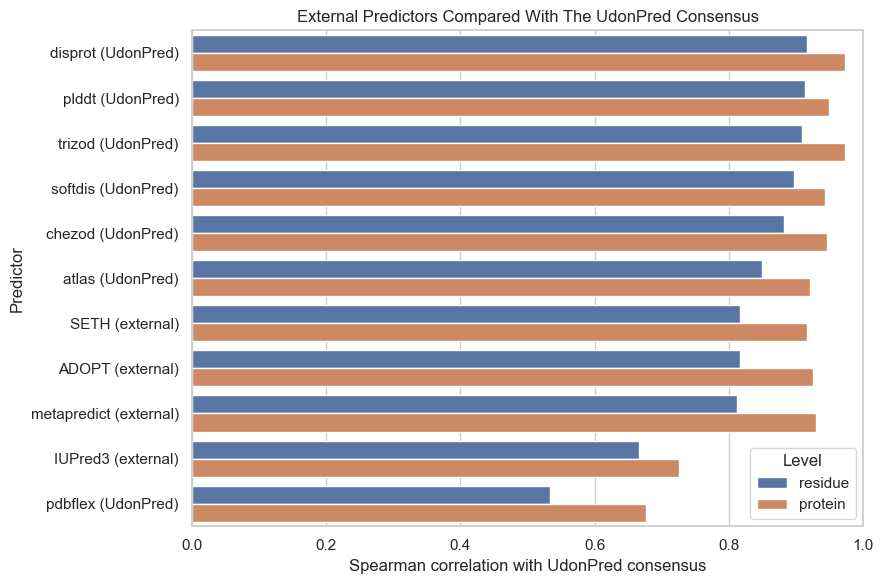

In [9]:
consensus_plot_data = predictor_vs_udon_consensus.melt(
    id_vars=["predictor", "comparison_group", "common_proteins", "matched_residues"],
    value_vars=["residue_spearman_vs_udon_consensus", "protein_spearman_vs_udon_consensus"],
    var_name="level",
    value_name="spearman_vs_consensus",
)
consensus_plot_data["level"] = consensus_plot_data["level"].map(
    {
        "residue_spearman_vs_udon_consensus": "residue",
        "protein_spearman_vs_udon_consensus": "protein",
    }
)
consensus_plot_data["predictor_label"] = np.where(
    consensus_plot_data["comparison_group"] == "external predictor",
    consensus_plot_data["predictor"] + " (external)",
    consensus_plot_data["predictor"] + " (UdonPred)",
)
order = (
    predictor_vs_udon_consensus.sort_values("residue_spearman_vs_udon_consensus", ascending=False)
    .assign(
        predictor_label=lambda frame: np.where(
            frame["comparison_group"] == "external predictor",
            frame["predictor"] + " (external)",
            frame["predictor"] + " (UdonPred)",
        )
    )["predictor_label"]
    .tolist()
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=consensus_plot_data,
    x="spearman_vs_consensus",
    y="predictor_label",
    hue="level",
    order=order,
)
plt.xlabel("Spearman correlation with UdonPred consensus")
plt.ylabel("Predictor")
plt.title("External Predictors Compared With The UdonPred Consensus")
plt.xlim(0, 1)
plt.legend(title="Level", loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_vs_udonpred_consensus.png", dpi=200)
plt.show()


## Contested Regions

The contested-region table ranks fixed windows by disagreement after z-score scaling predictor outputs. These regions are candidates for follow-up inspection rather than model-performance errors, because no human-proteome ground truth is assumed here.


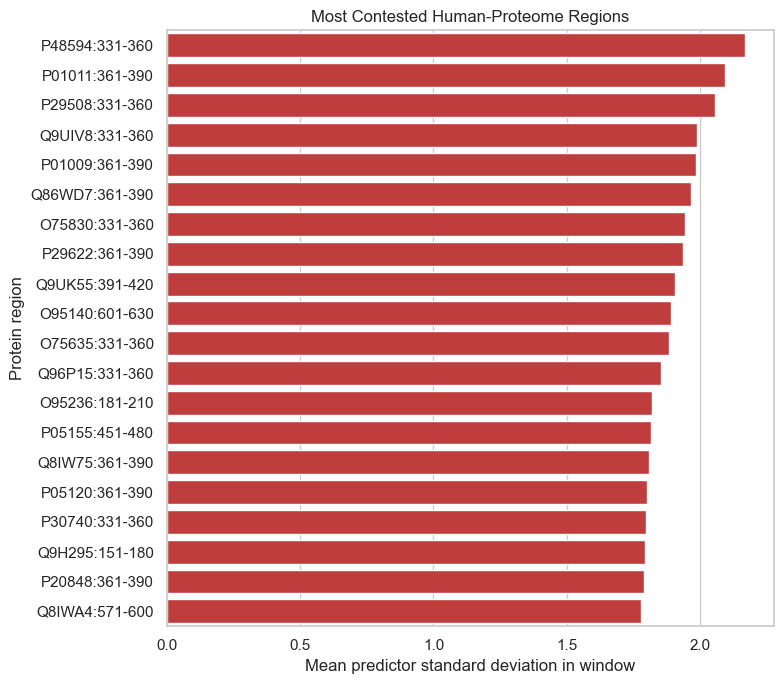

,protein_id,start_residue,end_residue,mean_std,max_std,max_range,max_disagreement_residue,mean_score
0,P48594,331,360,2.17022,3.24599,11.90340,344,0.619233
1,P01011,361,390,2.09489,3.17564,11.58140,373,0.550390
2,P29508,331,360,2.05569,3.34633,12.21770,342,0.733154
3,Q9UIV8,331,360,1.98814,3.18027,11.54750,343,0.570113
4,P01009,361,390,1.98538,3.15559,11.61580,370,0.381772
5,Q86WD7,361,390,1.96706,3.19779,11.80240,366,0.567095
6,O75830,331,360,1.94263,3.13530,11.49660,346,0.472719
7,P29622,361,390,1.93603,3.23225,11.80980,377,0.407750
8,Q9UK55,391,420,1.90606,3.07822,11.36830,396,0.252256
9,O95140,601,630,1.89359,2.38496,9.47962,611,0.778924


In [10]:
contested_display_columns = [
    "protein_id",
    "start_residue",
    "end_residue",
    "mean_std",
    "max_std",
    "max_range",
    "max_disagreement_residue",
    "mean_score",
]
contested_top = contested_regions.sort_values(["mean_std", "max_std"], ascending=False).head(20).copy()
contested_top["region"] = (
    contested_top["protein_id"].astype(str)
    + ":"
    + contested_top["start_residue"].astype(str)
    + "-"
    + contested_top["end_residue"].astype(str)
)

plt.figure(figsize=(8, 7))
sns.barplot(data=contested_top, x="mean_std", y="region", color="tab:red")
plt.xlabel("Mean predictor standard deviation in window")
plt.ylabel("Protein region")
plt.title("Most Contested Human-Proteome Regions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_contested_regions.png", dpi=200)
plt.show()

contested_top[contested_display_columns]
